# Imports

In [41]:
import pandas as pd
from ImpararePackage import dataRequest

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn import tree

import joblib

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# Data download

In [42]:
query = """
    SELECT *
    FROM "imparare2_dataset_label_full"
    where "DIA_parsed" > to_date('2022-09-05', 'yyyy-mm-dd')
	    and "DIA_parsed" < to_date('2023-09-07', 'yyyy-mm-dd')
        and (
            "DIUR_count" is not null
            and "TEMP_count" is not null
            and "FC_count" is not null
        ) -- nao possui nenhum sinal vital 
"""

df = dataRequest.get_data(queryText= query, chunck= None)

In [43]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [44]:
df.head()

,REGISTRO,DIA_parsed,SEXO,IDADE,UNIDADE_INTERNACAO,ESPECIALIDADE_INTERNACAO,TIPO_INTERNACAO,CLINICA_INTERNACAO,dthr_internacao,dthr_alta,caso_infeccao,pnm,isc,itu,pav,ipcs,traqueobronquite,los_dias,los_horas,CIRURGIA_tempo_total,CIRURGIA_procedimentos_total,TECNICO(A) EM ENFERMAGEM_count,TECNICO(A) EM ENFERMAGEM_avg,ENFERMEIRO(A)_count,ENFERMEIRO(A)_avg,AUXILIAR DE ENFERMAGEM_count,AUXILIAR DE ENFERMAGEM_avg,ACADEMICODE ENFERMAGEM_count,ACADEMICO DE ENFERMAGEM_avg,MEDICO_count,MEDICO_avg,FISIOTERAPEUTA_count,FISIOTERAPEUTA_avg,OUTROS_count,OUTROS_avg,DIUR_min,DIUR_max,DIUR_count,DIUR_avg,DIUR_stddev,DIUR_delta,FC_min,FC_max,FC_count,FC_avg,FC_stddev,FC_delta,FR_min,FR_max,FR_count,FR_avg,FR_stddev,FR_delta,HGT_min,HGT_max,HGT_count,HGT_avg,HGT_stddev,HGT_delta,OXIMETRIA_min,OXIMETRIA_max,OXIMETRIA_count,OXIMETRIA_avg,OXIMETRIA_stddev,OXIMETRIA_delta,PAD_min,PAD_max,PAD_count,PAD_avg,PAD_stddev,PAD_delta,PAS_min,PAS_max,PAS_count,PAS_avg,PAS_stddev,PAS_delta,TEMP_min,TEMP_max,TEMP_count,TEMP_avg,TEMP_stddev,TEMP_delta,PA_min,PA_max,PA_count,PA_avg,PA_stddev,PA_delta,PAM_min,PAM_max,PAM_count,PAM_avg,PAM_stddev,PAM_delta,TEMP_INCUBADORA_min,TEMP_INCUBADORA_max,TEMP_INCUBADORA_count,TEMP_INCUBADORA_avg,TEMP_INCUBADORA_stddev,TEMP_INCUBADORA_delta,O2_min,O2_max,O2_count,O2_avg,O2_stddev,O2_delta,FIO2_min,FIO2_max,FIO2_count,FIO2_avg,FIO2_stddev,FIO2_delta,PEEP_min,PEEP_max,PEEP_count,PEEP_avg,PEEP_stddev,PEEP_delta,SINAIS_VITAIS_registros_total,FEBRE_indicada,UNIDADE_fim_janela,UNIDADE_inicio_janela,UNIDADE_movimento_total,EVOLUCAO_notas_total,EVOLUCAO_notas_total_dia,aciclovir_count,amoxicilina_sulbactam_count,cefadroxila_count,cefalotina_count,cefotaxima_count,ceftazidima_count,ceftazidima_avibactam_count,ceftalozana_tazobactam_count,cetoconazol_count,claritromicina_count,cloranfenicol_count,doxiciclina_count,ertapenem_count,eritromicina_count,ganciclovir_count,ivermectina_count,micafungina_count,miconazol_count,moxifloxacino_count,mupirocina_count,neomicina_count,rifampicina_count,sulfadiazina_count,teicoplanina_count,voriconazol_count,ciprofloxacino_count,outro_count,amicacina_count,amoxicilina_clavulanato_count,amoxicilina_count,ampicilina_count,azitromicina_count,penicilinagbenzatina_count,penicilinagpotassica_count,cefalexina_count,cefazolina_count,cefepima_count,ceftriaxona_count,cefuroxima_count,clindamicina_count,fluconazol_count,gentamicina_count,levofloxacino_count,linezolida_count,meropenem_count,metronidazol_count,nistatina_count,oxacilina_count,piperacilina_tazobactam_count,ampicilina_sulbactam_count,sulfametoxazol_trimetoprim_count,polimixinab_count,tobramicina_count,vancomicina_count,via_topico_count,via_sng_count,via_outro_count,via_ev_count,via_im_count,via_vo_count,agg_hemocultura,qtd_hemocultura_positiva,qtd_hemocultura_sem_crescimento,qtd_cultura_positiva,qtd_cultura_sem_crescimento,qtd_bacteroscopico_positiva,qtd_bacteroscopico_negativa,agg_urocultura,qtd_urocultura_positiva,qtd_urocultura_sem_crescimento,qtd_bacteriologico_positiva,qtd_bacteriologico_sem_crescimento,leuco_min,leuco_max,leuco_avg,rdw_min,rdw_max,rdw_avg,neuto_min,neuto_max,neuto_avg,RAGIOLOGIA_laudos_total,tosse,ronco,cavita,opac,infil,fibrose_cistica,sec_pur_pulmonar,secr,puru,secr_traq,o2,dpoc,hemoptise,leucemia,esplenectomia,febre,consol,linfoma,acinetobacter,amarelada,aspiracao,broncograma_aereo,crepitante,enterobacter,enterococcus,hemophylus,hipertermia,imunossuprimido,infeccao,klebsiella,legionella,leucocitose,leucopenia,moraxella,pneumococcus,pseudomonas,sibilos,intubacao,staphylococcus_aureus,sepse_pulmonar,sepse_respiratoria,sepse_urinaria,padrao_ventilatorio,insuficiencia_ventilatoria,esforco_ventilatorio,lavado_broncoalveolar,derrame_pleural,escherichia_coli,choque_septico,dor_pleuritica,dor_ventilatorio_dependente,ventilacao_mecanica,iot,pav_1,endoftalmite,eritema,hiperemia,mediastinite,staphylococcus_coagulase_negativo,supuracao,rubor,mal_estar,abscesso,calor,dreno,edema,endocardite,antibiotico,bacteriologico,deiscencia,resisten

# Data exploration

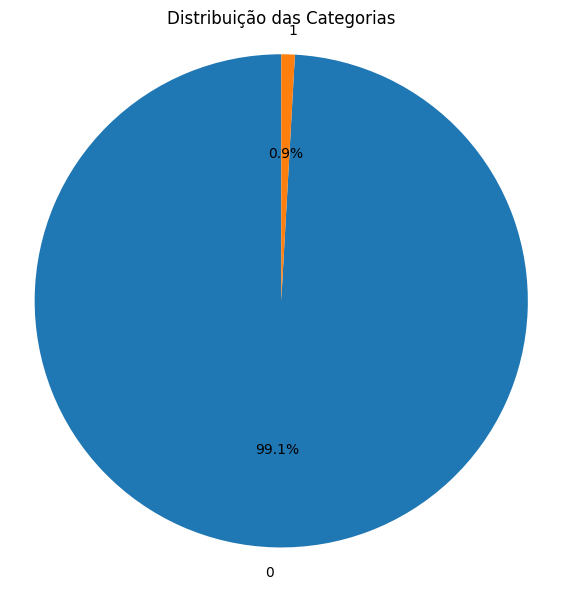

In [91]:
import matplotlib.pyplot as plt

counts = df['caso_infeccao'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribuição das Categorias')
plt.axis('equal')
plt.show()

In [58]:
# Dado controle - quem é e de quando é
dados_controle = ["REGISTRO", "DIA_parsed", "dthr_internacao", "dthr_alta"]

# Dado texto: 
dado_categoricos = ["UNIDADE_INTERNACAO", "ESPECIALIDADE_INTERNACAO", "TIPO_INTERNACAO", "CLINICA_INTERNACAO", "SEXO", "TEMP_INCUBADORA_min", "TEMP_INCUBADORA_max", "TEMP_INCUBADORA_count", "TEMP_INCUBADORA_avg", "TEMP_INCUBADORA_stddev", "TEMP_INCUBADORA_delta", "UNIDADE_fim_janela", "UNIDADE_inicio_janela", "agg_hemocultura", "agg_urocultura"]

# Gabaritos
gabaritos = ["caso_infeccao", "pnm", "isc", "itu", "pav", "ipcs", "traqueobronquite"]

# Features
features_atendimento = ["IDADE", "los_dias", "los_horas"]

features_cirurgias = ["CIRURGIA_tempo_total", "CIRURGIA_procedimentos_total"]

# Sinais vitais
features_sinal_vital = ["TECNICO(A) EM ENFERMAGEM_count", "TECNICO(A) EM ENFERMAGEM_avg", "ENFERMEIRO(A)_count", "ENFERMEIRO(A)_avg", "AUXILIAR DE ENFERMAGEM_count", "AUXILIAR DE ENFERMAGEM_avg", "ACADEMICODE ENFERMAGEM_count", "ACADEMICO DE ENFERMAGEM_avg", "MEDICO_count", "MEDICO_avg", "FISIOTERAPEUTA_count", "FISIOTERAPEUTA_avg", "OUTROS_count", "OUTROS_avg", "DIUR_min", "DIUR_max", "DIUR_count", "DIUR_avg", "DIUR_stddev", "DIUR_delta", "FC_min", "FC_max", "FC_count", "FC_avg", "FC_stddev", "FC_delta", "FR_min", "FR_max", "FR_count", "FR_avg", "FR_stddev", "FR_delta", "HGT_min", "HGT_max", "HGT_count", "HGT_avg", "HGT_stddev", "HGT_delta", "OXIMETRIA_min", "OXIMETRIA_max", "OXIMETRIA_count", "OXIMETRIA_avg", "OXIMETRIA_stddev", "OXIMETRIA_delta", "PAD_min", "PAD_max", "PAD_count", "PAD_avg", "PAD_stddev", "PAD_delta", "PAS_min", "PAS_max", "PAS_count", "PAS_avg", "PAS_stddev", "PAS_delta", "TEMP_min", "TEMP_max", "TEMP_count", "TEMP_avg", "TEMP_stddev", "TEMP_delta", "PA_min", "PA_max", "PA_count", "PA_avg", "PA_stddev", "PA_delta", "PAM_min", "PAM_max", "PAM_count", "PAM_avg", "PAM_stddev", "PAM_delta", "O2_min", "O2_max", "O2_count", "O2_avg", "O2_stddev", "O2_delta", "FIO2_min", "FIO2_max", "FIO2_count", "FIO2_avg", "FIO2_stddev", "FIO2_delta", "PEEP_min", "PEEP_max", "PEEP_count", "PEEP_avg", "PEEP_stddev", "PEEP_delta", "SINAIS_VITAIS_registros_total", "FEBRE_indicada"]

# Volumetrico evos e movimentacao
features_evol = ["UNIDADE_movimento_total", "EVOLUCAO_notas_total", "EVOLUCAO_notas_total_dia"]

# Antibioticos utilizados
features_atb = ["aciclovir_count", "amoxicilina_sulbactam_count", "cefadroxila_count", "cefalotina_count", "cefotaxima_count", "ceftazidima_count", "ceftazidima_avibactam_count", "ceftalozana_tazobactam_count", "cetoconazol_count", "claritromicina_count", "cloranfenicol_count", "doxiciclina_count", "ertapenem_count", "eritromicina_count", "ganciclovir_count", "ivermectina_count", "micafungina_count", "miconazol_count", "moxifloxacino_count", "mupirocina_count", "neomicina_count", "rifampicina_count", "sulfadiazina_count", "teicoplanina_count", "voriconazol_count", "ciprofloxacino_count", "outro_count", "amicacina_count", "amoxicilina_clavulanato_count", "amoxicilina_count", "ampicilina_count", "azitromicina_count", "penicilinagbenzatina_count", "penicilinagpotassica_count", "cefalexina_count", "cefazolina_count", "cefepima_count", "ceftriaxona_count", "cefuroxima_count", "clindamicina_count", "fluconazol_count", "gentamicina_count", "levofloxacino_count", "linezolida_count", "meropenem_count", "metronidazol_count", "nistatina_count", "oxacilina_count", "piperacilina_tazobactam_count", "ampicilina_sulbactam_count", "sulfametoxazol_trimetoprim_count", "polimixinab_count", "tobramicina_count", "vancomicina_count", "via_topico_count", "via_sng_count", "via_outro_count", "via_ev_count", "via_im_count", "via_vo_count"]

# Dados de exame
# Culturais
features_culturais = ["qtd_hemocultura_positiva", "qtd_hemocultura_sem_crescimento", "qtd_cultura_positiva", "qtd_cultura_sem_crescimento", "qtd_bacteroscopico_positiva", "qtd_bacteroscopico_negativa", "qtd_urocultura_positiva", "qtd_urocultura_sem_crescimento", "qtd_bacteriologico_positiva", "qtd_bacteriologico_sem_crescimento"]

# Sangue
features_sangue = ["leuco_min", "leuco_max", "leuco_avg", "rdw_min", "rdw_max", "rdw_avg", "neuto_min", "neuto_max", "neuto_avg"]

# Laudos Imagem
features_laudos_imagem = ["RAGIOLOGIA_laudos_total"]

# Proporção de termos no texto 
features_proporcao_texto = ["tosse", "ronco", "cavita", "opac", "infil", "fibrose_cistica", "sec_pur_pulmonar", "secr", "puru", "secr_traq", "o2", "dpoc", "hemoptise", "leucemia", "esplenectomia", "febre", "consol", "linfoma", "acinetobacter", "amarelada", "aspiracao", "broncograma_aereo", "crepitante", "enterobacter", "enterococcus", "hemophylus", "hipertermia", "imunossuprimido", "infeccao", "klebsiella", "legionella", "leucocitose", "leucopenia", "moraxella", "pneumococcus", "pseudomonas", "sibilos", "intubacao", "staphylococcus_aureus", "sepse_pulmonar", "sepse_respiratoria", "sepse_urinaria", "padrao_ventilatorio", "insuficiencia_ventilatoria", "esforco_ventilatorio", "lavado_broncoalveolar", "derrame_pleural", "escherichia_coli", "choque_septico", "dor_pleuritica", "dor_ventilatorio_dependente", "ventilacao_mecanica", "iot", "pav_1", "endoftalmite", "eritema", "hiperemia", "mediastinite", "staphylococcus_coagulase_negativo", "supuracao", "rubor", "mal_estar", "abscesso", "calor", "dreno", "edema", "endocardite", "antibiotico", "bacteriologico", "deiscencia", "resistente", "taquicardia", "cateter", "cateter_arterial", "cateter_urinario", "cvc", "cateter_venoso_periferico", "clorose", "instabilidade", "oliguria", "hipotensao", "anuria", "bacteremia", "bacteriuria", "disuria", "leucocituria", "nitrito", "svd", "tsa", "choque", "staphylococcus", "e_coli", "colecao", "tremor", "calafrio", "pos_operatorio", "dor_suprapubica", "foco_urinario", "colite_pseudomembranosa", "yersinia", "vomito", "shigella", "salmonela", "nausea", "giardia", "dor_cabeca", "dor_abdominal", "diarreia", "clostridium", "campylobacter", "urgencia_urinaria", "urgencia_miccional", "sondagem_alivio", "sondagem_vesical", "urocultura", "piuria", "albumina", "press_parc_co2", "bicarbonato", "calcio", "creatinina", "glicose", "hemoglobina", "plaquetas", "potassio", "sodio", "bilirrubina", "cardiomegalia", "lesao_pulmonar", "pneumonia", "atelectasia", "pneumotorax", "fratura", "freq_respiratoria", "freq_cardiaca", "pressao_sanguinea", "saturacao_sangue", "hemocultura", "temperatura", "ph_sangue", "propionibacterium", "cryptococcus", "pneumocystis", "histoplasma", "paracoccidioides", "bacteroides", "candida", "fusobacterium", "peptostreptococcus", "sibilancia", "hipotermia", "apneia", "bradicardia", "streptococcus_viridans", "consciencia", "hcm", "hgm", "corynebacterium", "bacillus", "aerococcus", "coccidioides", "veillonella", "covid", "peep", "fio2", "spo2", "avc", "sne", "desnutricao", "sedacao", "vsg", "fosfatase_alcalina", "ldh", "cetamina", "propofol", "clorpromazina", "fentanil", "pancuronio", "noradrenalina", "diazepan", "lorazepan", "flumazenil", "clonidina", "npt", "cateter_monolumen", "cateter_duplolumen", "cateter_triplolumen", "portocath", "cateter_hickmann", "shilley", "obesidade", "diabetes", "neutropenia", "tabagismo"]

# contagem de termos em texto
features_contagem_texto = ["tosse_pos_count", "ronco_pos_count", "cavita_pos_count", "opac_pos_count", "infil_pos_count", "fibrose_cistica_pos_count", "sec_pur_pulmonar_pos_count", "secr_pos_count", "puru_pos_count", "secr_traq_pos_count", "o2_pos_count", "dpoc_pos_count", "hemoptise_pos_count", "leucemia_pos_count", "esplenectomia_pos_count", "febre_pos_count", "consol_pos_count", "linfoma_pos_count", "acinetobacter_pos_count", "amarelada_pos_count", "aspiracao_pos_count", "broncograma_aereo_pos_count", "crepitante_pos_count", "enterobacter_pos_count", "enterococcus_pos_count", "hemophylus_pos_count", "hipertermia_pos_count", "imunossuprimido_pos_count", "infeccao_pos_count", "klebsiella_pos_count", "legionella_pos_count", "leucocitose_pos_count", "leucopenia_pos_count", "moraxella_pos_count", "pneumococcus_pos_count", "pseudomonas_pos_count", "sibilos_pos_count", "intubacao_pos_count", "staphylococcus_aureus_pos_count", "sepse_pulmonar_pos_count", "sepse_respiratoria_pos_count", "sepse_urinaria_pos_count", "padrao_ventilatorio_pos_count", "insuficiencia_ventilatoria_pos_count", "esforco_ventilatorio_pos_count", "lavado_broncoalveolar_pos_count", "derrame_pleural_pos_count", "escherichia_coli_pos_count", "choque_septico_pos_count", "dor_pleuritica_pos_count", "dor_ventilatorio_dependente_pos_count", "ventilacao_mecanica_pos_count", "iot_pos_count", "pav_pos_count", "endoftalmite_pos_count", "eritema_pos_count", "hiperemia_pos_count", "mediastinite_pos_count", "staphylococcus_coagulase_negativo_pos_count", "supuracao_pos_count", "rubor_pos_count", "mal_estar_pos_count", "abscesso_pos_count", "calor_pos_count", "dreno_pos_count", "edema_pos_count", "endocardite_pos_count", "antibiotico_pos_count", "bacteriologico_pos_count", "deiscencia_pos_count", "resistente_pos_count", "taquicardia_pos_count", "cateter_pos_count", "cateter_arterial_pos_count", "cateter_urinario_pos_count", "cvc_pos_count", "cateter_venoso_periferico_pos_count", "clorose_pos_count", "instabilidade_pos_count", "oliguria_pos_count", "hipotensao_pos_count", "anuria_pos_count", "bacteremia_pos_count", "bacteriuria_pos_count", "disuria_pos_count", "leucocituria_pos_count", "nitrito_pos_count", "svd_pos_count", "tsa_pos_count", "choque_pos_count", "staphylococcus_pos_count", "e_coli_pos_count", "colecao_pos_count", "tremor_pos_count", "calafrio_pos_count", "pos_operatorio_pos_count", "dor_suprapubica_pos_count", "foco_urinario_pos_count", "colite_pseudomembranosa_pos_count", "yersinia_pos_count", "vomito_pos_count", "shigella_pos_count", "salmonela_pos_count", "nausea_pos_count", "giardia_pos_count", "dor_cabeca_pos_count", "dor_abdominal_pos_count", "diarreia_pos_count", "clostridium_pos_count", "campylobacter_pos_count", "urgencia_urinaria_pos_count", "urgencia_miccional_pos_count", "sondagem_alivio_pos_count", "sondagem_vesical_pos_count", "urocultura_pos_count", "piuria_pos_count", "albumina_pos_count", "press_parc_co2_pos_count", "bicarbonato_pos_count", "calcio_pos_count", "creatinina_pos_count", "glicose_pos_count", "hemoglobina_pos_count", "plaquetas_pos_count", "potassio_pos_count", "sodio_pos_count", "bilirrubina_pos_count", "cardiomegalia_pos_count", "lesao_pulmonar_pos_count", "pneumonia_pos_count", "atelectasia_pos_count", "pneumotorax_pos_count", "fratura_pos_count", "freq_respiratoria_pos_count", "freq_cardiaca_pos_count", "pressao_sanguinea_pos_count", "saturacao_sangue_pos_count", "hemocultura_pos_count", "temperatura_pos_count", "ph_sangue_pos_count", "propionibacterium_pos_count", "cryptococcus_pos_count", "pneumocystis_pos_count", "histoplasma_pos_count", "paracoccidioides_pos_count", "bacteroides_pos_count", "candida_pos_count", "fusobacterium_pos_count", "peptostreptococcus_pos_count", "sibilancia_pos_count", "hipotermia_pos_count", "apneia_pos_count", "bradicardia_pos_count", "streptococcus_viridans_pos_count", "consciencia_pos_count", "hcm_pos_count", "hgm_pos_count", "corynebacterium_pos_count", "bacillus_pos_count", "aerococcus_pos_count", "coccidioides_pos_count", "veillonella_pos_count", "covid_pos_count", "peep_pos_count", "fio2_pos_count", "spo2_pos_count", "avc_pos_count", "sne_pos_count", "desnutricao_pos_count", "sedacao_pos_count", "vsg_pos_count", "fosfatase_alcalina_pos_count", "ldh_pos_count", "cetamina_pos_count", "propofol_pos_count", "clorpromazina_pos_count", "fentanil_pos_count", "pancuronio_pos_count", "noradrenalina_pos_count", "diazepan_pos_count", "lorazepan_pos_count", "flumazenil_pos_count", "clonidina_pos_count", "npt_pos_count", "cateter_monolumen_pos_count", "cateter_duplolumen_pos_count", "cateter_triplolumen_pos_count", "portocath_pos_count", "cateter_hickmann_pos_count", "shilley_pos_count", "obesidade_pos_count", "diabetes_pos_count", "neutropenia_pos_count", "tabagismo_pos_count"]


## DF - Gabarito + Textos

In [71]:
df_texto_gabarito = df[gabaritos+features_proporcao_texto+features_contagem_texto]
df_texto_gabarito.head()

,caso_infeccao,pnm,isc,itu,pav,ipcs,traqueobronquite,tosse,ronco,cavita,opac,infil,fibrose_cistica,sec_pur_pulmonar,secr,puru,secr_traq,o2,dpoc,hemoptise,leucemia,esplenectomia,febre,consol,linfoma,acinetobacter,amarelada,aspiracao,broncograma_aereo,crepitante,enterobacter,enterococcus,hemophylus,hipertermia,imunossuprimido,infeccao,klebsiella,legionella,leucocitose,leucopenia,moraxella,pneumococcus,pseudomonas,sibilos,intubacao,staphylococcus_aureus,sepse_pulmonar,sepse_respiratoria,sepse_urinaria,padrao_ventilatorio,insuficiencia_ventilatoria,esforco_ventilatorio,lavado_broncoalveolar,derrame_pleural,escherichia_coli,choque_septico,dor_pleuritica,dor_ventilatorio_dependente,ventilacao_mecanica,iot,pav_1,endoftalmite,eritema,hiperemia,mediastinite,staphylococcus_coagulase_negativo,supuracao,rubor,mal_estar,abscesso,calor,dreno,edema,endocardite,antibiotico,bacteriologico,deiscencia,resistente,taquicardia,cateter,cateter_arterial,cateter_urinario,cvc,cateter_venoso_periferico,clorose,instabilidade,oliguria,hipotensao,anuria,bacteremia,bacteriuria,disuria,leucocituria,nitrito,svd,tsa,choque,staphylococcus,e_coli,colecao,tremor,calafrio,pos_operatorio,dor_suprapubica,foco_urinario,colite_pseudomembranosa,yersinia,vomito,shigella,salmonela,nausea,giardia,dor_cabeca,dor_abdominal,diarreia,clostridium,campylobacter,urgencia_urinaria,urgencia_miccional,sondagem_alivio,sondagem_vesical,urocultura,piuria,albumina,press_parc_co2,bicarbonato,calcio,creatinina,glicose,hemoglobina,plaquetas,potassio,sodio,bilirrubina,cardiomegalia,lesao_pulmonar,pneumonia,atelectasia,pneumotorax,fratura,freq_respiratoria,freq_cardiaca,pressao_sanguinea,saturacao_sangue,hemocultura,temperatura,ph_sangue,propionibacterium,cryptococcus,pneumocystis,histoplasma,paracoccidioides,bacteroides,candida,fusobacterium,peptostreptococcus,sibilancia,hipotermia,apneia,bradicardia,streptococcus_viridans,consciencia,hcm,hgm,corynebacterium,bacillus,aerococcus,coccidioides,veillonella,covid,peep,fio2,spo2,avc,sne,desnutricao,sedacao,vsg,fosfatase_alcalina,ldh,cetamina,propofol,clorpromazina,fentanil,pancuronio,noradrenalina,diazepan,lorazepan,flumazenil,clonidina,npt,cateter_monolumen,cateter_duplolumen,cateter_triplolumen,portocath,cateter_hickmann,shilley,obesidade,diabetes,neutropenia,tabagismo,tosse_pos_count,ronco_pos_count,cavita_pos_count,opac_pos_count,infil_pos_count,fibrose_cistica_pos_count,sec_pur_pulmonar_pos_count,secr_pos_count,puru_pos_count,secr_traq_pos_count,o2_pos_count,dpoc_pos_count,hemoptise_pos_count,leucemia_pos_count,esplenectomia_pos_count,febre_pos_count,consol_pos_count,linfoma_pos_count,acinetobacter_pos_count,amarelada_pos_count,aspiracao_pos_count,broncograma_aereo_pos_count,crepitante_pos_count,enterobacter_pos_count,enterococcus_pos_count,hemophylus_pos_count,hipertermia_pos_count,imunossuprimido_pos_count,infeccao_pos_count,klebsiella_pos_count,legionella_pos_count,leucocitose_pos_count,leucopenia_pos_count,moraxella_pos_count,pneumococcus_pos_count,pseudomonas_pos_count,sibilos_pos_count,intubacao_pos_count,staphylococcus_aureus_pos_count,sepse_pulmonar_pos_count,sepse_respiratoria_pos_count,sepse_urinaria_pos_count,padrao_ventilatorio_pos_count,insuficiencia_ventilatoria_pos_count,esforco_ventilatorio_pos_count,lavado_broncoalveolar_pos_count,derrame_pleural_pos_count,escherichia_coli_pos_count,choque_septico_pos_count,dor_pleuritica_pos_count,dor_ventilatorio_dependente_pos_count,ventilacao_mecanica_pos_count,iot_pos_count,pav_pos_count,endoftalmite_pos_count,eritema_pos_count,hiperemia_pos_count,mediastinite_pos_count,staphylococcus_coagulase_negativo_pos_count,supuracao_pos_count,rubor_pos_count,mal_estar_pos_count,abscesso_pos_count,calor_pos_count,dreno_pos_count,edema_pos_count,endocardite_pos_count,antibiotico_pos_count,bacteriologico_pos_count,deiscencia_pos_count,resistente_pos_count,taquicardia_pos_count,cateter_pos_count,cateter_arterial_pos_count,cateter_urinario_pos_count,cvc_pos_count,cateter_venoso_periferico_pos_count,c

In [72]:
X_texto = df_texto_gabarito.drop(columns= gabaritos)
y_texto = df_texto_gabarito['caso_infeccao']
X_texto_train, X_texto_test, y_texto_train, y_texto_test = train_test_split(X_texto, y_texto, test_size=0.33, random_state=42, stratify= y_texto)
len(X_texto_train), len(X_texto_test), len(y_texto_train), len(y_texto_test)

(45675, 22498, 45675, 22498)

## DF - Gabarito + Sinal_vital

In [ ]:
df_sinal_vital_gabarito = df[gabaritos+features_sinal_vital]
df_sinal_vital_gabarito.head()

,caso_infeccao,pnm,isc,itu,pav,ipcs,traqueobronquite,TECNICO(A) EM ENFERMAGEM_count,TECNICO(A) EM ENFERMAGEM_avg,ENFERMEIRO(A)_count,ENFERMEIRO(A)_avg,AUXILIAR DE ENFERMAGEM_count,AUXILIAR DE ENFERMAGEM_avg,ACADEMICODE ENFERMAGEM_count,ACADEMICO DE ENFERMAGEM_avg,MEDICO_count,MEDICO_avg,FISIOTERAPEUTA_count,FISIOTERAPEUTA_avg,OUTROS_count,OUTROS_avg,DIUR_min,DIUR_max,DIUR_count,DIUR_avg,DIUR_stddev,DIUR_delta,FC_min,FC_max,FC_count,FC_avg,FC_stddev,FC_delta,FR_min,FR_max,FR_count,FR_avg,FR_stddev,FR_delta,HGT_min,HGT_max,HGT_count,HGT_avg,HGT_stddev,HGT_delta,OXIMETRIA_min,OXIMETRIA_max,OXIMETRIA_count,OXIMETRIA_avg,OXIMETRIA_stddev,OXIMETRIA_delta,PAD_min,PAD_max,PAD_count,PAD_avg,PAD_stddev,PAD_delta,PAS_min,PAS_max,PAS_count,PAS_avg,PAS_stddev,PAS_delta,TEMP_min,TEMP_max,TEMP_count,TEMP_avg,TEMP_stddev,TEMP_delta,PA_min,PA_max,PA_count,PA_avg,PA_stddev,PA_delta,PAM_min,PAM_max,PAM_count,PAM_avg,PAM_stddev,PAM_delta,O2_min,O2_max,O2_count,O2_avg,O2_stddev,O2_delta,FIO2_min,FIO2_max,FIO2_count,FIO2_avg,FIO2_stddev,FIO2_delta,PEEP_min,PEEP_max,PEEP_count,PEEP_avg,PEEP_stddev,PEEP_delta,SINAIS_VITAIS_registros_total,FEBRE_indicada
0,0,0,0,0,0,0,0,32.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,0,NaN,NaN,NaN,134.0000,158.0000,6,148.5000,8.4083,0.0000,50.0000,52.0000,6,51.1667,0.9832,1.0000,NaN,NaN,0,NaN,NaN,NaN,95.0000,100.0000,6,97.8333,2.0412,-2.0000,30.0000,48.0000,2,39.0000,12.7279,-18.0000,NaN,NaN,0,NaN,NaN,NaN,36.2000,36.9000,7,36.6429,0.2225,0.1000,75.0000,79.0000,2,77.0000,2.8284,4.0000,47.0000,54.0000,2,50.5000,4.9497,25.0000,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,32,0
1,0,0,0,0,0,0,0,39.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,0,NaN,NaN,NaN,150.0000,180.0000,8,163.2500,8.2937,3.0000,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,95.0000,99.0000,8,97.3750,1.5059,3.0000,NaN,NaN,0,NaN,NaN,NaN,64.0000,99.0000,2,81.5000,24.7487,35.0000,36.5000,36.9000,8,36.7250,0.1282,0.0000,32.0000,40.0000,2,36.0000,5.6569,8.0000,42.0000,66.0000,2,54.0000,16.9706,-2.0000,NaN,NaN,0,NaN,NaN,NaN,21.0000,21.0000,4,21.0000,0.0000,0.0000,6.0000,6.0000,3,6.0000,0.0000,0.0000,39,0
2,0,0,0,0,0,0,0,9.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,0,NaN,NaN,NaN,130.0000,141.0000,3,133.6667,6.3509,11.0000,39.0000,43.0000,2,41.0000,2.8284,-4.0000,NaN,NaN,0,NaN,NaN,NaN,94.0000,97.0000,2,95.5000,2.1213,3.0000,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,36.7000,37.1000,2,36.9000,0.2828,-0.4000,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,9,0
3,0,0,0,0,0,0,0,21.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,0,NaN,NaN,NaN,96.0000,122.0000,7,104.2857,12.1204,-26.0000,23.0000,26.0000,3,24.3333,1.5275,3.0000,NaN,NaN,0,NaN,NaN,NaN,94.0000,99.0000,4,97.0000,2.1602,3.0000,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,35.9000,37.4000,4,36.6750,0.7365,-0.2000,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,21,0
4,0,0,0,0,0,0,0,32.0000,0.8421,6.0000,0.1579,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,0,NaN,NaN,NaN,123.0000,188.0000,6,156.0000,24.7629,26.0000,32.0000,60.0000,6,51.3333,11.6390,28.0000,NaN,NaN,0,NaN,NaN,NaN,97.0000,99.0000,7,97.7143,0.7559,-1.0000,NaN,NaN,0,NaN,NaN,NaN,71.0000,109.0000,4,95.7500,17.6895,24.0000,35.8000,38.1000,7,37.2714,0.7783,-0.5000,31.0000,57.0000,4,50.5000,13.0000,26.0000,40.0000,76.0000,4,65.0000,16.8523,17.0000,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,38,1


In [62]:
X_SINAL_VITAL = df_sinal_vital_gabarito.drop(columns= gabaritos)
y_sinal_vital = df_sinal_vital_gabarito['caso_infeccao']
X_sinal_vital_train, X_sinal_vital_test, y_sinal_vital_train, y_sinal_vital_test = train_test_split(X_SINAL_VITAL, y_sinal_vital, test_size=0.33, random_state=42, stratify= y_sinal_vital)
len(X_sinal_vital_train), len(X_sinal_vital_test), len(y_sinal_vital_train), len(y_sinal_vital_test)

(45675, 22498, 45675, 22498)

# Split df

In [92]:
X = df.drop(columns= ["TEMP_INCUBADORA_min", "TEMP_INCUBADORA_max", "TEMP_INCUBADORA_count", "TEMP_INCUBADORA_avg", "TEMP_INCUBADORA_stddev", "TEMP_INCUBADORA_delta",'REGISTRO', 'los_horas', 'caso_infeccao', 'pnm', 'isc', 'itu', 'pav', 'ipcs', 'traqueobronquite', 'DIA_parsed', 'SEXO', 'UNIDADE_INTERNACAO', 'UNIDADE_INTERNACAO', 'ESPECIALIDADE_INTERNACAO', 'TIPO_INTERNACAO',	'CLINICA_INTERNACAO', 'dthr_internacao', 'dthr_alta', 'UNIDADE_fim_janela', 'UNIDADE_inicio_janela', 'agg_hemocultura', 'agg_urocultura'])
y = df['caso_infeccao']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify= y)

In [93]:
len(X_train), len(X_test), len(y_train), len(y_test)

(45675, 22498, 45675, 22498)

# Train

## DT

### GridSearch DT

In [94]:
# Modelo base
dt = DecisionTreeClassifier(random_state= 28)

# Grid de parâmetros para testar
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],            # medida de impureza
    'max_depth': list(range(1, 100)).append(None),        # profundidade máxima
    'min_samples_split': [2, 5, 10, 20],         # mín. amostras para dividir um nó
    'min_samples_leaf': [1, 2, 4, 8],            # mín. amostras em uma folha
    'max_features': [None, 'sqrt', 'log2'],      # nº de features consideradas por vez
    'splitter': ['best', 'random']
}

# GridSearch
grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,                 # 5-fold cross validation
    scoring='recall',   # métrica (pode trocar para f1, recall, etc.)
    n_jobs=30,            # usar todos os cores disponíveis
    verbose=3
)

# Treinar o grid
grid.fit(X_train, y_train)

TypeError: Parameter grid for parameter 'max_depth' needs to be a list or a numpy array, but got None (of type NoneType) instead. Single values need to be wrapped in a list with one element.

In [ ]:
# Melhor modelo encontrado
print("Melhores parâmetros:", grid.best_params_)
print("Melhor score:", grid.best_score_)

# Modelo final
model = grid.best_estimator_

In [ ]:
y_train_pred = model.predict(X_train)
acc = accuracy_score(y_train, y_train_pred)
print(f"Accurácia: {acc}")
cm = confusion_matrix(y_train, y_train_pred)
print(f"Confusion Matrix treino: \n{cm}\n")
report = classification_report(y_train, y_train_pred)
print(report)

print("\n=========================================================\n")
# Validando test
y_pred = model.predict(X_test)
    
acc = accuracy_score(y_test, y_pred)
print(f"Accurácia: {acc}")
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix teste: \n{cm}")
report = classification_report(y_test, y_pred)
print(report)

In [ ]:
pd.options.display.float_format = '{:.4f}'.format
importances = pd.Series(model.feature_importances_, index=X_train.columns)

# Ordena em ordem decrescente
importances = importances.sort_values(ascending=False)
print(importances)

importances = importances.to_dict()
importances['model'] = 'random_forest'
# model.append(importances)

### DT - From best estimator params

In [85]:
# END criterion=log_loss, max_depth=15, max_features=None, min_samples_leaf=1, min_samples_split=2, splitter=random;, score=0.842 total time=  23.7s
model = DecisionTreeClassifier(
    criterion='entropy', 
    splitter='random', 
    random_state= 28, 
    min_samples_leaf= 2,
    min_samples_split= 3,
    max_features= None,
    max_depth= 18,
    class_weight= {0: 1, 1: 20}
)

model.fit(X_texto_train, y_texto_train)

,criterion,'entropy'
,splitter,'random'
,max_depth,18
,min_samples_split,3
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,28
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,"{0: 1, 1: 20}"


In [86]:
y_train_pred = model.predict(X_texto_train)
acc = accuracy_score(y_train, y_train_pred)
print(f"Accurácia: {acc}")
cm = confusion_matrix(y_train, y_train_pred)
print(f"Confusion Matrix treino: \n{cm}\n")
report = classification_report(y_train, y_train_pred)
print(report)

print("\n=========================================================\n")
# Validando test
y_pred = model.predict(X_texto_test)
    
acc = accuracy_score(y_test, y_pred)
print(f"Accurácia: {acc}")
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix teste: \n{cm}")
report = classification_report(y_test, y_pred)
print(report)

Accurácia: 0.9989490968801313
Confusion Matrix treino: 
[[45225    46]
 [    2   402]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45271
           1       0.90      1.00      0.94       404

    accuracy                           1.00     45675
   macro avg       0.95      1.00      0.97     45675
weighted avg       1.00      1.00      1.00     45675



Accurácia: 0.9952884700862299
Confusion Matrix teste: 
[[22233    66]
 [   40   159]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22299
           1       0.71      0.80      0.75       199

    accuracy                           1.00     22498
   macro avg       0.85      0.90      0.87     22498
weighted avg       1.00      1.00      1.00     22498



In [88]:
pd.options.display.float_format = '{:.4f}'.format
importances = pd.Series(model.feature_importances_, index=X_texto_test.columns)

# Ordena em ordem decrescente
importances = importances.sort_values(ascending=False)
print(importances)

importances = importances.to_dict()
importances['model'] = 'random_forest'
# model.append(importances)

cateter                                       0.1273
secr                                          0.0767
febre                                         0.0403
hemocultura                                   0.0393
pos_operatorio                                0.0303
leucemia                                      0.0303
consciencia_pos_count                         0.0256
instabilidade                                 0.0243
noradrenalina                                 0.0219
dreno                                         0.0218
tosse                                         0.0201
clostridium                                   0.0176
lorazepan                                     0.0174
deiscencia                                    0.0154
infil_pos_count                               0.0142
choque_septico                                0.0139
edema                                         0.0128
temperatura                                   0.0128
avc                                           

In [90]:
text_tree = tree.export_text(model, feature_names=X_texto.columns)
print(text_tree)

|--- cateter <= 0.06
|   |--- secr <= 0.22
|   |   |--- noradrenalina <= 0.03
|   |   |   |--- temperatura <= 0.44
|   |   |   |   |--- instabilidade <= 0.31
|   |   |   |   |   |--- neutropenia_pos_count <= 1.61
|   |   |   |   |   |   |--- propofol <= 0.60
|   |   |   |   |   |   |   |--- bacteremia_pos_count <= 12.18
|   |   |   |   |   |   |   |   |--- consciencia_pos_count <= 6.26
|   |   |   |   |   |   |   |   |   |--- obesidade <= 0.05
|   |   |   |   |   |   |   |   |   |   |--- hiperemia_pos_count <= 6.12
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 8
|   |   |   |   |   |   |   |   |   |   |--- hiperemia_pos_count >  6.12
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |   |   |   |   |   |   |--- obesidade >  0.05
|   |   |   |   |   |   |   |   |   |   |--- spo2 <= 0.01
|   |   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |   |   |--- spo2 >  0.01
|   |   |   |   |  

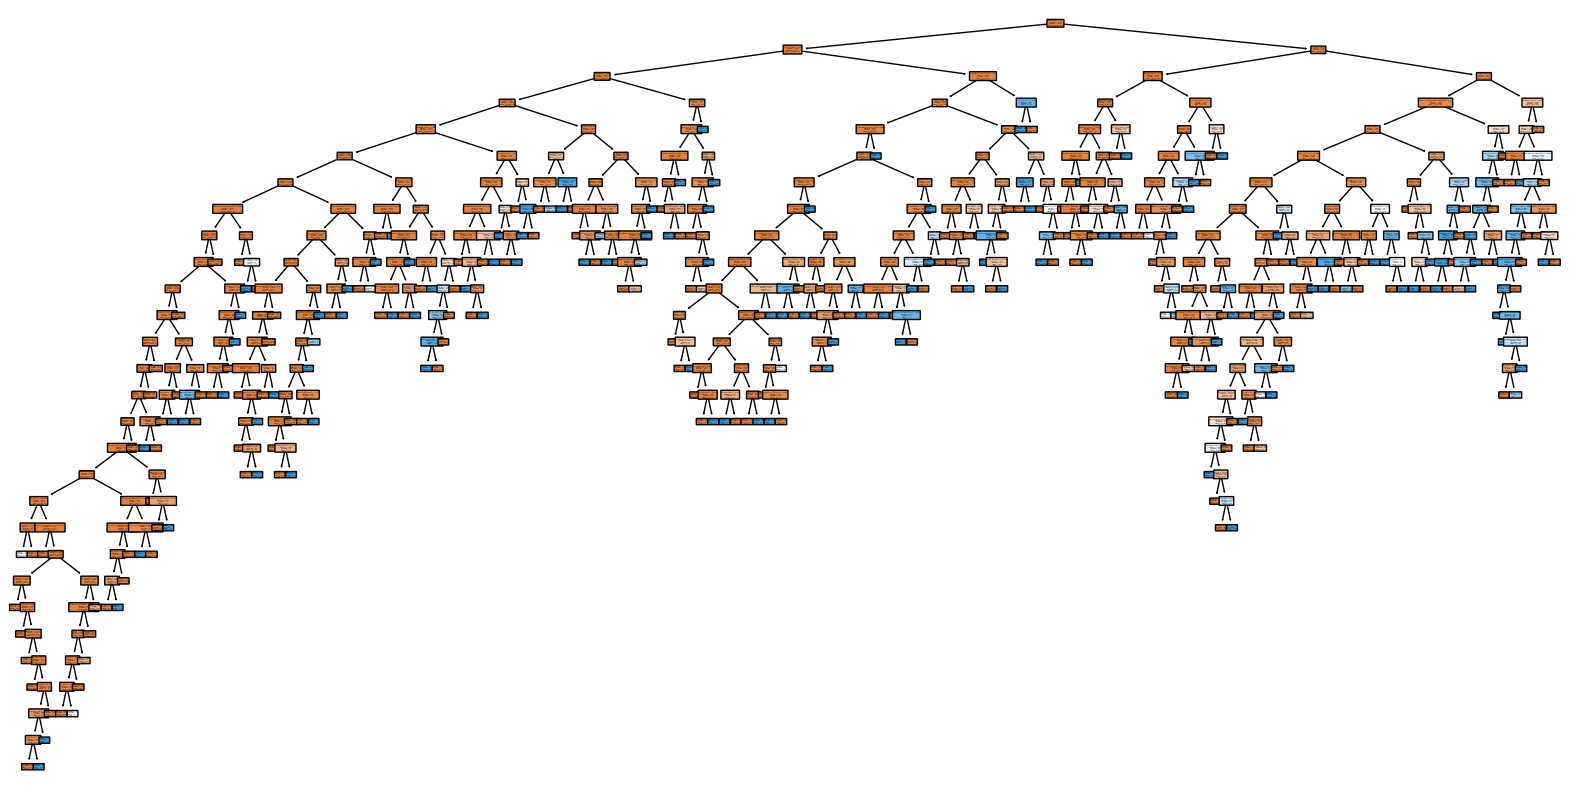

In [ ]:
plt.figure(figsize=(20, 10))
tree.plot_tree(
    model,
    feature_names=X.columns,
    class_names=[str(c) for c in model.classes_],
    filled=True,
    rounded=True
)
plt.show()


# Xgboost

### Grid 

In [25]:
param_grid = {
    'xgb__n_estimators':list(range(1, 1000)),
    'xgb__max_depth': [3, 4, 5],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0],
    'xgb__eval_metric': ['logloss']
}

In [ ]:
pipeline = Pipeline([
    ('xgb', XGBClassifier())
])

In [26]:


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='recall',
    cv=skf,
    n_jobs=-1,
    verbose=3
)

In [27]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 35964 candidates, totalling 179820 fits
[CV 3/5] END xgb__colsample_bytree=0.8, xgb__eval_metric=logloss, xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=1, xgb__subsample=0.8;, score=0.000 total time=   3.6s
[CV 5/5] END xgb__colsample_bytree=0.8, xgb__eval_metric=logloss, xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=1, xgb__subsample=1.0;, score=0.000 total time=   3.7s
[CV 3/5] END xgb__colsample_bytree=0.8, xgb__eval_metric=logloss, xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=1, xgb__subsample=1.0;, score=0.000 total time=   3.7s
[CV 5/5] END xgb__colsample_bytree=0.8, xgb__eval_metric=logloss, xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=1, xgb__subsample=0.8;, score=0.000 total time=   3.8s
[CV 2/5] END xgb__colsample_bytree=0.8, xgb__eval_metric=logloss, xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=1, xgb__subsample=0.8;, score=0.000 total time=   3.7s
[CV 1/5] END xgb__cols

Exception ignored on calling ctypes callback function <bound method DataIter._next_wrapper of <xgboost.data.SingleBatchInternalIter object at 0x7e9cce779130>>:
Traceback (most recent call last):
  File "/workspaces/imparare-surface-materdei-neo/.venv/lib/python3.13/site-packages/xgboost/core.py", line 630, in _next_wrapper
    def _next_wrapper(self, this: None) -> int:  # pylint: disable=unused-argument
KeyboardInterrupt: 
Exception ignored on calling ctypes callback function <bound method DataIter._next_wrapper of <xgboost.data.SingleBatchInternalIter object at 0x7f8901d59130>>:
Traceback (most recent call last):
  File "/workspaces/imparare-surface-materdei-neo/.venv/lib/python3.13/site-packages/xgboost/core.py", line 630, in _next_wrapper
    def _next_wrapper(self, this: None) -> int:  # pylint: disable=unused-argument
KeyboardInterrupt: 
Exception ignored on calling ctypes callback function <bound method DataIter._next_wrapper of <xgboost.data.SingleBatchInternalIter object at 0x

[CV 2/5] END xgb__colsample_bytree=0.8, xgb__eval_metric=logloss, xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=17, xgb__subsample=0.8;, score=nan total time=   1.5s
[CV 3/5] END xgb__colsample_bytree=0.8, xgb__eval_metric=logloss, xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=17, xgb__subsample=0.8;, score=nan total time=   1.5s
[CV 4/5] END xgb__colsample_bytree=0.8, xgb__eval_metric=logloss, xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=17, xgb__subsample=0.8;, score=nan total time=   1.3s
[CV 5/5] END xgb__colsample_bytree=0.8, xgb__eval_metric=logloss, xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=17, xgb__subsample=0.8;, score=nan total time=   1.3s
[CV 1/5] END xgb__colsample_bytree=0.8, xgb__eval_metric=logloss, xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=17, xgb__subsample=1.0;, score=nan total time=   1.2s
[CV 2/5] END xgb__colsample_bytree=0.8, xgb__eval_metric=logloss, xgb__learning_rate=0.01, xgb_

KeyboardInterrupt: 

In [19]:
model = grid.best_estimator_
y_train_pred = model.predict(X_train)
acc = accuracy_score(y_train, y_train_pred)
print(f"Accurácia: {acc}")
cm = confusion_matrix(y_train, y_train_pred)
print(f"Confusion Matrix treino: \n{cm}\n")
report = classification_report(y_train, y_train_pred)
print(report)

print("\n=========================================================\n")
# Validando test
y_pred = model.predict(X_test)
    
acc = accuracy_score(y_test, y_pred)
print(f"Accurácia: {acc}")
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix teste: \n{cm}")
report = classification_report(y_test, y_pred)
print(report)

Accurácia: 0.9998686371100164
Confusion Matrix treino: 
[[45271     0]
 [    6   398]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45271
           1       1.00      0.99      0.99       404

    accuracy                           1.00     45675
   macro avg       1.00      0.99      1.00     45675
weighted avg       1.00      1.00      1.00     45675



Accurácia: 0.9962663347853142
Confusion Matrix teste: 
[[22297     2]
 [   82   117]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22299
           1       0.98      0.59      0.74       199

    accuracy                           1.00     22498
   macro avg       0.99      0.79      0.87     22498
weighted avg       1.00      1.00      1.00     22498



In [20]:
print("Melhores parâmetros:", grid.best_params_)
print("Melhor score:", grid.best_score_)

Melhores parâmetros: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 300, 'xgb__subsample': 1.0}
Melhor score: 0.9961466885604817


In [35]:
from joblib import Parallel, delayed
from tqdm import tqdm
import itertools
import numpy as np
from sklearn.model_selection import KFold

def evaluate_params(model_class, params, X, y, metric_fn, k):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in kf.split(X):
        model = model_class(**params)
        model.fit(X[train_idx], y[train_idx])
        preds = model.predict(X[val_idx])
        scores.append(metric_fn(y[val_idx], preds))

    return params, np.mean(scores)

def parallel_grid_search_tqdm(model_class, param_grid, X, y, metric_fn, k=5, n_jobs=-1):
    keys = list(param_grid.keys())
    combinations = [dict(zip(keys, vals)) for vals in itertools.product(*param_grid.values())]

    results = []

    with tqdm(total=len(combinations), desc="Grid Search", unit="comb") as pbar:

        # aqui não há captura de tqdm dentro da função
        parallel = Parallel(n_jobs=n_jobs)

        tasks = (
            delayed(evaluate_params)(model_class, params, X, y, metric_fn, k)
            for params in combinations
        )

        for result in parallel(tasks):
            results.append(result)
            pbar.update(1)  # somente o processo principal atualiza

    best_params, best_score = max(results, key=lambda x: x[1])
    return best_params, best_score, results

In [40]:
from sklearn.metrics import accuracy_score, recall_score
from xgboost import XGBClassifier

param_grid = {
    "max_depth": [3, 4, 5],
    "learning_rate": list(range(1, 100, 1)/100),
    "n_estimators": list(range(1, 101, 10)),
    "subsample": [0.8, 1.0],
}

best_params, best_score, results = parallel_grid_search_tqdm(
    XGBClassifier,
    param_grid,
    X.values,
    y.values,
    recall_score,
    k=5,
    n_jobs=-1
)

print("Melhores parâmetros:", best_params)
print("Melhor score:", best_score)

TypeError: unsupported operand type(s) for /: 'range' and 'int'